# **CUSTOMER CHURN PREDICTION**

**About Dataset :**


Context
"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]
Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.


**The data set includes information about:**

1) Customers who left within the last month – the column is called Churn

2) Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies

3) Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges

4) Demographic info about customers – gender, age range, and if they have partners and dependents

# Libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 1. to handle the data
import pandas as pd
import numpy as np
from scipy import stats

# to visualize the data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
# import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
#for classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# pipeline
from sklearn.pipeline import Pipeline
# metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error,mean_squared_error,r2_score

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Read Data

In [4]:
# load dataset
df = pd.read_csv('/content/drive/MyDrive/BVP_DATASETS/WA_Fn-UseC_-Telco-Customer-Churn.csv')
# print all column
pd.set_option('display.max_columns', None)
# print first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA

# Info Of Columns


In [5]:
# check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 




*   By Using Info Function We Can See Count Of Columns And Rows DataType Of Data And Missing Values Also.In The Data 2 Columns Are of Int datatype And 1 Float Datatype And 18 Are Object Datatype .

*   In The Data 7043 Rows And 21 Columns .

*   In The Data 2 Columns Are of Int datatype 1 Column Float Datatype And 18 Columns Are Object Datatype .
*  In The Data TotalCharges Column Is Float Datatype But It Show Object Datatype






In [6]:
# convert datatype for 'TotalCharges'
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
# drop missing values
df.dropna(inplace=True)

# drop customerID
df.drop('customerID', axis=1, inplace=True)

Summary Of Numerical Columns


In [8]:
# summary dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


Check Unique Values


In [9]:
# apply loop check unique value without int or float in dataset
for col in df.columns:
    if df[col].dtype != 'int64' and df[col].dtype != 'float64':
        print(f'{col} : {df[col].unique()}')

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


Check Missing Values

In [10]:
# check missing value
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


<Axes: >

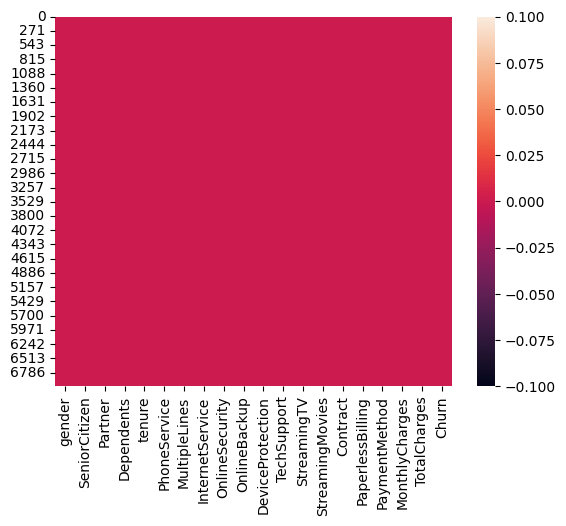

In [11]:
# heatmap for missing value
sns.heatmap(df.isnull())

# Visualization


In This Dataset 85.71% Is Data Object DataType And 14.29%iIs Numerical Data || I Used Count Plot For Describe These Object Columns With Respect To Churn Column

Customer Churn "Customer Churn" is a binary concept, meaning customers either churn (leave or stop doing business with a company) or they don't. It is a simple yes or no question – either a customer has churned or they have not

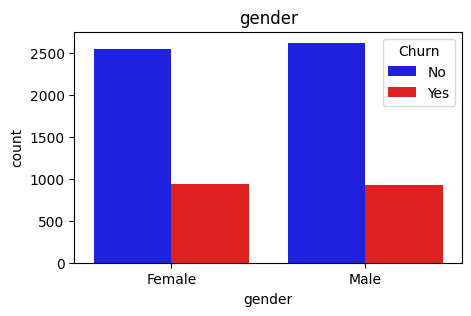

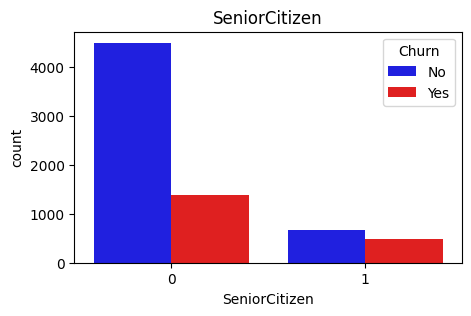

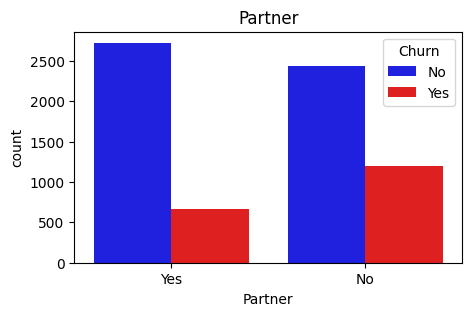

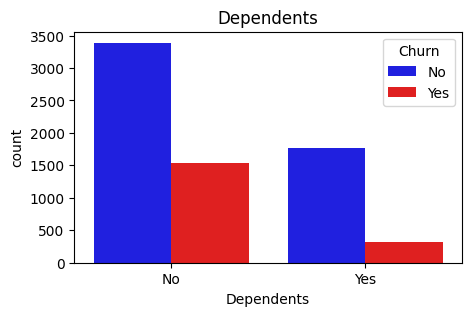

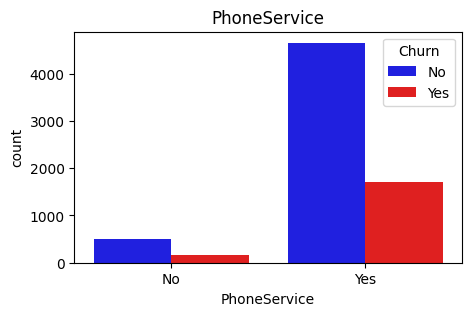

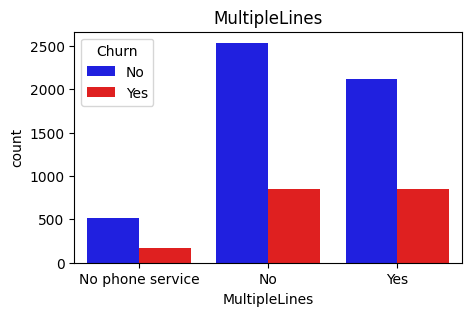

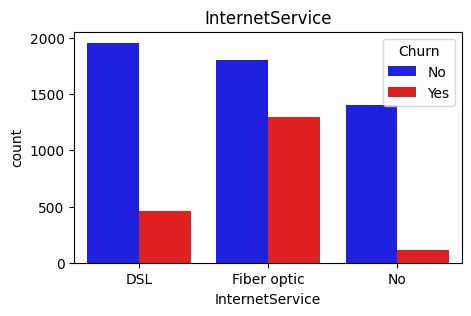

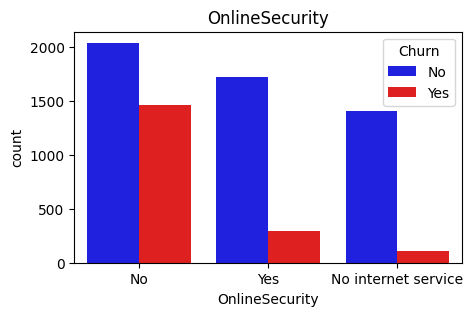

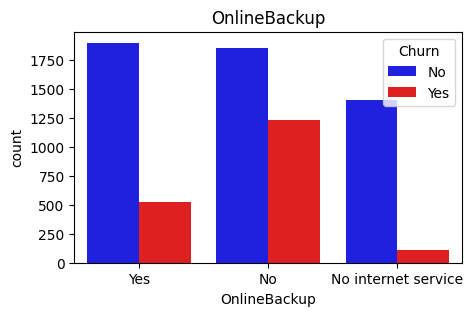

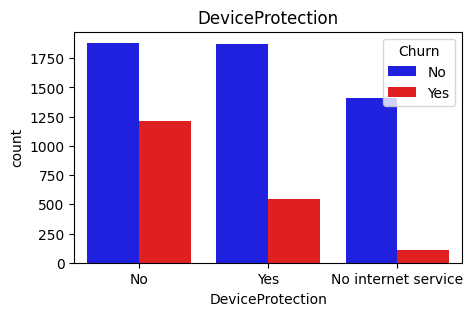

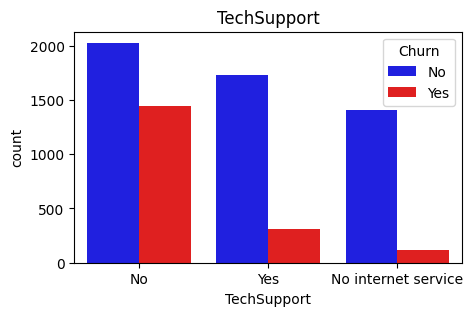

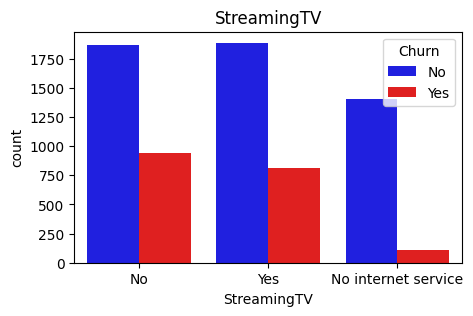

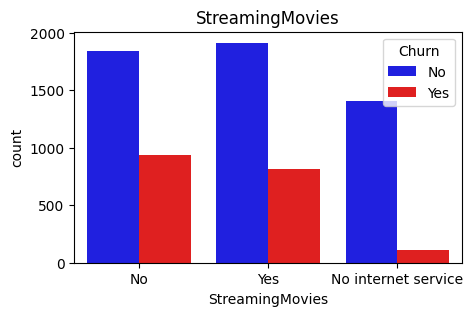

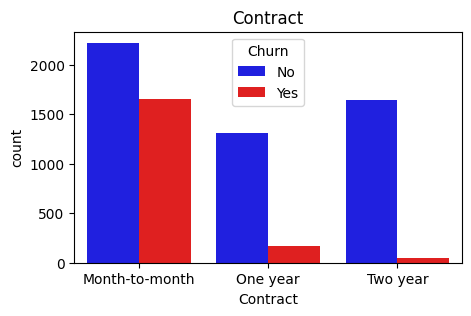

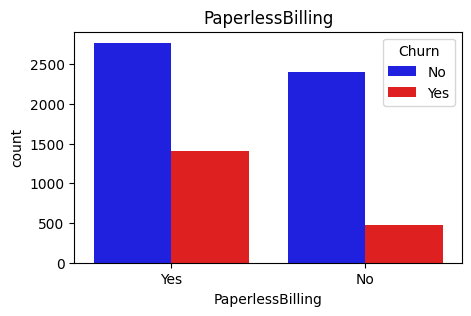

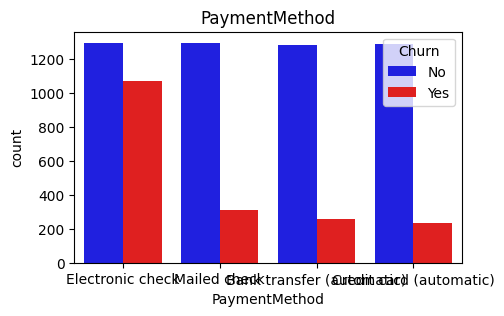

In [12]:

# Define colors for Yes and No
colors = {'Yes': 'red', 'No': 'blue'}

# Add missing keys for 0 and 1 in the palette
palette = {0: 'blue', 1: 'red'}

for i, predictor in enumerate(df.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges', 'tenure'])):
    plt.figure(i, figsize=(5, 3))
    sns.countplot(data=df, x=predictor, hue='Churn', palette=colors)
    plt.title(predictor)
    plt.show()


# Numerical Data

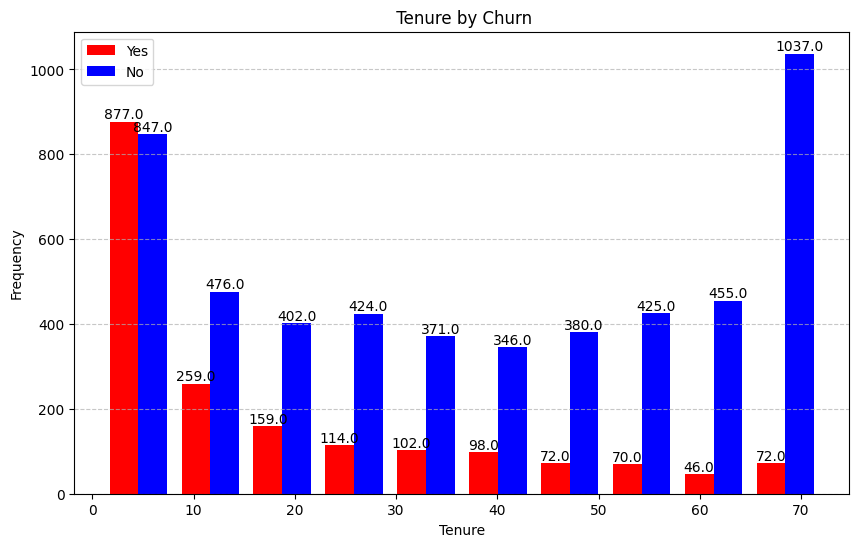

In [13]:
# make plot for tenure
churned = df[df['Churn'] == 'Yes']
not_churned = df[df['Churn'] == 'No']

# Plotting
plt.figure(figsize=(10, 6))
plt.hist([churned['tenure'], not_churned['tenure']], bins=10, color=['red', 'blue'], label=['Yes', 'No'])
plt.title(' Tenure by Churn')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add text on top of bars
for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')


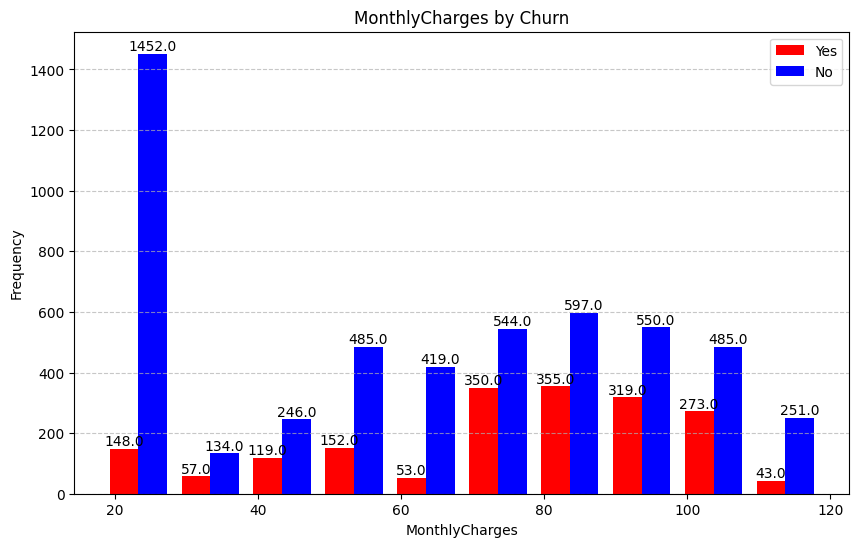

In [14]:
# make plot for MonthlyCharges
churned = df[df['Churn'] == 'Yes']
not_churned = df[df['Churn'] == 'No']

# Plotting
plt.figure(figsize=(10, 6))
plt.hist([churned['MonthlyCharges'], not_churned['MonthlyCharges']], bins=10, color=['red', 'blue'], label=['Yes', 'No'])
plt.title('MonthlyCharges by Churn')
plt.xlabel('MonthlyCharges')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add text on top of bars
for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')


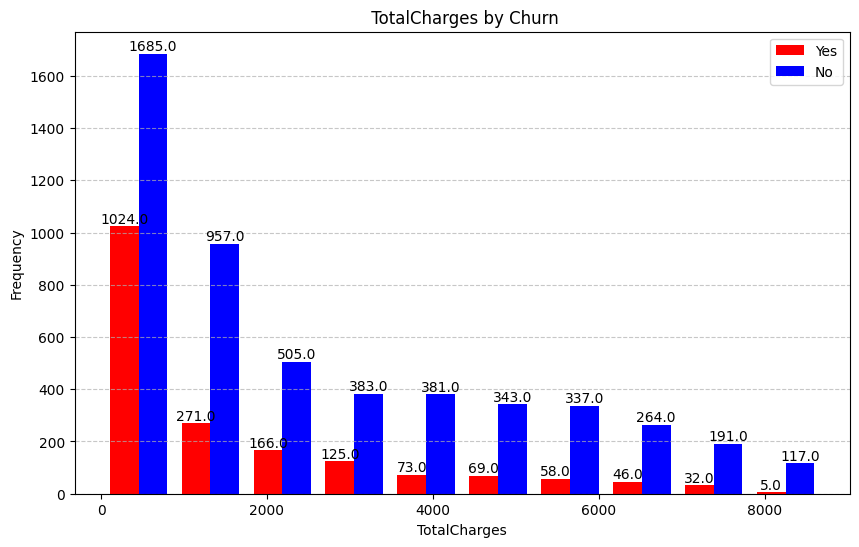

In [15]:
# make plot for tenure
churned = df[df['Churn'] == 'Yes']
not_churned = df[df['Churn'] == 'No']

# Plotting
plt.figure(figsize=(10, 6))
plt.hist([churned['TotalCharges'], not_churned['TotalCharges']], bins=10, color=['red', 'blue'], label=['Yes', 'No'])
plt.title(' TotalCharges by Churn')
plt.xlabel('TotalCharges')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add text on top of bars
for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')


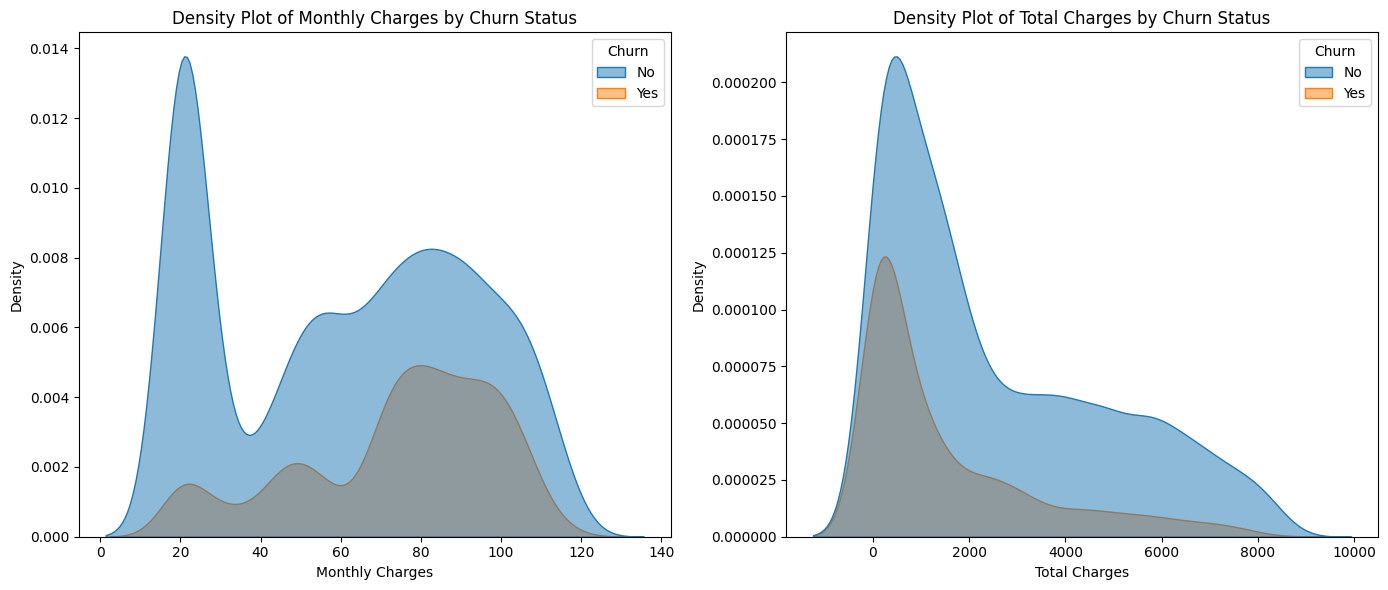

In [16]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Monthly Charges
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, alpha=0.5, ax=axes[0])
axes[0].set_title('Density Plot of Monthly Charges by Churn Status')
axes[0].set_xlabel('Monthly Charges')
axes[0].set_ylabel('Density')

# Plot for Total Charges
sns.kdeplot(data=df, x="TotalCharges", hue="Churn", fill=True, alpha=0.5, ax=axes[1])
axes[1].set_title('Density Plot of Total Charges by Churn Status')
axes[1].set_xlabel('Total Charges')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()


# **Customers With Lower Monthly Charge Are More Likely To Churn**

# Machine Learning

Encode The Data By OneHotEncoder


In [17]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['category', 'object']).columns

# Apply OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)  # Setting drop='first' to avoid multicollinearity
encoded_data = encoder.fit_transform(df[categorical_cols])

# Create a DataFrame from the encoded data
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))

# Drop the original categorical columns from the DataFrame
df.drop(columns=categorical_cols, inplace=True)

# Reset index of the DataFrame
df.reset_index(drop=True, inplace=True)

# Concatenate the original DataFrame with the encoded DataFrame
df = pd.concat([df, encoded_df], axis=1)

In [18]:

df.drop('Churn_No', axis=1, inplace=True)

In [19]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0,34,56.95,1889.50,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,2,53.85,108.15,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3,0,45,42.30,1840.75,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,2,70.70,151.65,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [20]:
# rename churn_yes to churn
df.rename(columns={'Churn_Yes': 'Churn'}, inplace=True)

In [21]:
# split data into X and y
X = df.drop('Churn', axis=1)
y = df['Churn']
# data into train and split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [22]:
# Initialize an empty list to store model scores
model_scores = []

# Create a list of models to evaluate
models = [
    ('Random Forest', RandomForestClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__max_depth': [None, 10, 20]}),  # Add hyperparameters for Random Forest
    ('Support Vector Machine', SVC(random_state=42, class_weight='balanced'),
        {'model__C': [0.1, 1, 10],
         'model__gamma': ['scale', 'auto']}),  # Add hyperparameters for SVM
    ('Logistic Regression', LogisticRegression(random_state=42, class_weight='balanced'),
        {'model__C': [0.1, 1, 10],
         'model__penalty': ['l1', 'l2']}),  # Add hyperparameters for Logistic Regression
    ('K-Nearest Neighbors', KNeighborsClassifier(),
        {'model__n_neighbors': [3, 5, 7],
         'model__weights': ['uniform', 'distance']}),  # Add hyperparameters for KNN
    ('Decision Tree', DecisionTreeClassifier(random_state=42),
        {'model__max_depth': [None, 10, 20],
         'model__min_samples_split': [2, 5, 10]}),  # Add hyperparameters for Decision Tree
]

best_model = None
best_accuracy = 0.0

# Iterate over the models and evaluate their performance
for name, model, param_grid in models:
    # Create a pipeline for each model
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),  # Feature Scaling
        ('model', model)
    ])

    # Hyperparameter tuning using GridSearchCV
    if param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=2)
        grid_search.fit(X_train, y_train)
        pipeline = grid_search.best_estimator_

    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = pipeline.predict(X_test)

    # Calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)

    # Append model name and accuracy to the list
    model_scores.append({'Model': name, 'Accuracy': accuracy})

    # Convert the list to a DataFrame
    scores_df = pd.DataFrame(model_scores)
    # Print the performance metrics
    print("Model:", name)
    print(f"Test Accuracy: {accuracy:.3f}%")
    print()

    # Check if the current model has the best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# Retrieve the overall best model
print("Best Model:")
print("Test Accuracy:", best_accuracy)
print(f"Model Pipeline: {best_model} with accuracy {best_accuracy:.2f}%")

Model: Random Forest
Test Accuracy: 0.810%

Model: Support Vector Machine
Test Accuracy: 0.737%

Model: Logistic Regression
Test Accuracy: 0.748%

Model: K-Nearest Neighbors
Test Accuracy: 0.768%

Model: Decision Tree
Test Accuracy: 0.765%

Best Model:
Test Accuracy: 0.8095238095238095
Model Pipeline: Pipeline(steps=[('scaler', MinMaxScaler()),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        random_state=42))]) with accuracy 0.81%


Plot Of Accuracy

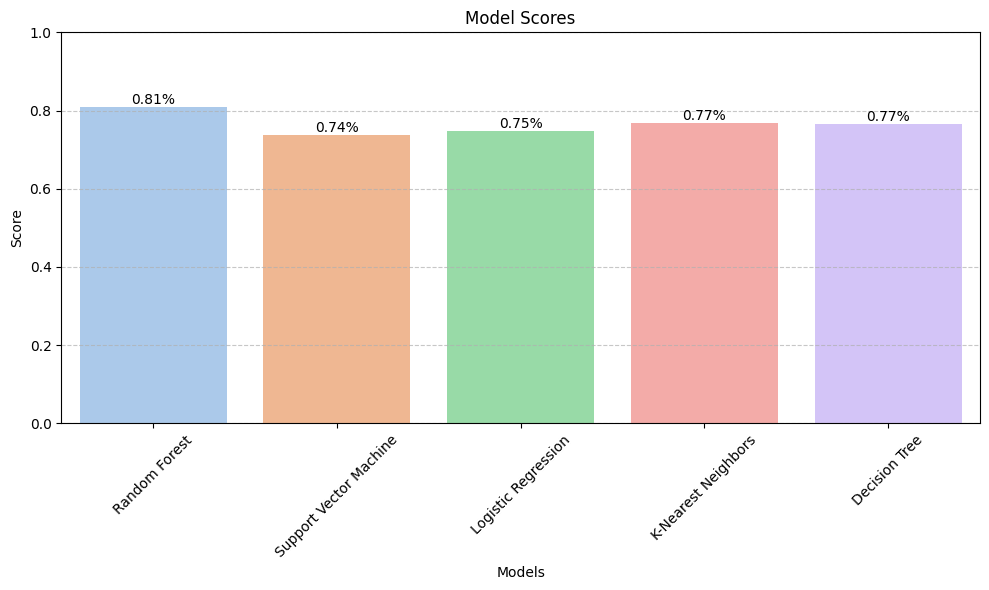

In [23]:
# Define a color palette for the bars
colors = sns.color_palette('pastel', n_colors=len(scores_df))

# Create a bar plot of models and their scores
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Accuracy', data=scores_df, palette=colors)

# Add text on each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Model Scores')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [24]:
from imblearn.combine import SMOTEENN
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
import pandas as pd
from scipy.stats import uniform, randint

# UpSampling
sm = SMOTEENN()
X_res, y_res = sm.fit_resample(X, y)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_res, y_res, test_size=0.2)

# Initialize an empty list to store model scores
model_scores = []

# Create a list of models to evaluate
models = [
    ('Random Forest', RandomForestClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__max_depth': [None, 10, 20]}),  # Add hyperparameters for Random Forest
    ('Support Vector Machine', SVC(random_state=42, class_weight='balanced'),
        {'model__C': [0.1, 1, 10],
         'model__gamma': ['scale', 'auto']}),  # Add hyperparameters for SVM
    ('Logistic Regression', LogisticRegression(random_state=42, class_weight='balanced'),
        {'model__C': [0.1, 1, 10],
         'model__penalty': ['l1', 'l2']}),  # Add hyperparameters for Logistic Regression
    ('K-Nearest Neighbors', KNeighborsClassifier(),
        {'model__n_neighbors': [3, 5, 7],
         'model__weights': ['uniform', 'distance']}),  # Add hyperparameters for KNN
    ('Decision Tree', DecisionTreeClassifier(random_state=42),
        {'model__max_depth': [None, 10, 20],
         'model__min_samples_split': [2, 5, 10]}),  # Add hyperparameters for Decision Tree
]

best_model = None
best_accuracy = 0.0

# Iterate over the models and evaluate their performance
for name, model, param_grid in models:
    # Create a pipeline for each model
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),  # Feature Scaling
        ('model', model)
    ])

    # Hyperparameter tuning using GridSearchCV for other models
    if param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=2, verbose=0)
        grid_search.fit(Xr_train, yr_train)
        pipeline = grid_search.best_estimator_

    # Fit the pipeline on the training data
    pipeline.fit(Xr_train, yr_train)

    # Make predictions on the test data
    y_pred = pipeline.predict(Xr_test)

    # Calculate accuracy score
    accuracy = accuracy_score(yr_test, y_pred)

    # Append model name and accuracy to the list
    model_scores.append({'Model': name, 'Accuracy': accuracy})

    # Convert the list to a DataFrame
    scores_df = pd.DataFrame(model_scores)

    # Print the performance metrics
    print("Model:", name)
    print(f"Test Accuracy:{accuracy:.3f}%")
    print()

    # Check if the current model has the best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# Retrieve the overall best model
print("Best Model:")
print("Test Accuracy:", best_accuracy)
print(f"Model Pipeline: {best_model} with accuracy {best_accuracy:.2f}%")

Model: Random Forest
Test Accuracy:0.950%

Model: Support Vector Machine
Test Accuracy:0.931%

Model: Logistic Regression
Test Accuracy:0.893%

Model: K-Nearest Neighbors
Test Accuracy:0.892%

Model: Decision Tree
Test Accuracy:0.927%

Best Model:
Test Accuracy: 0.9500846023688664
Model Pipeline: Pipeline(steps=[('scaler', MinMaxScaler()),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))]) with accuracy 0.95%


Plot Of Accuracy

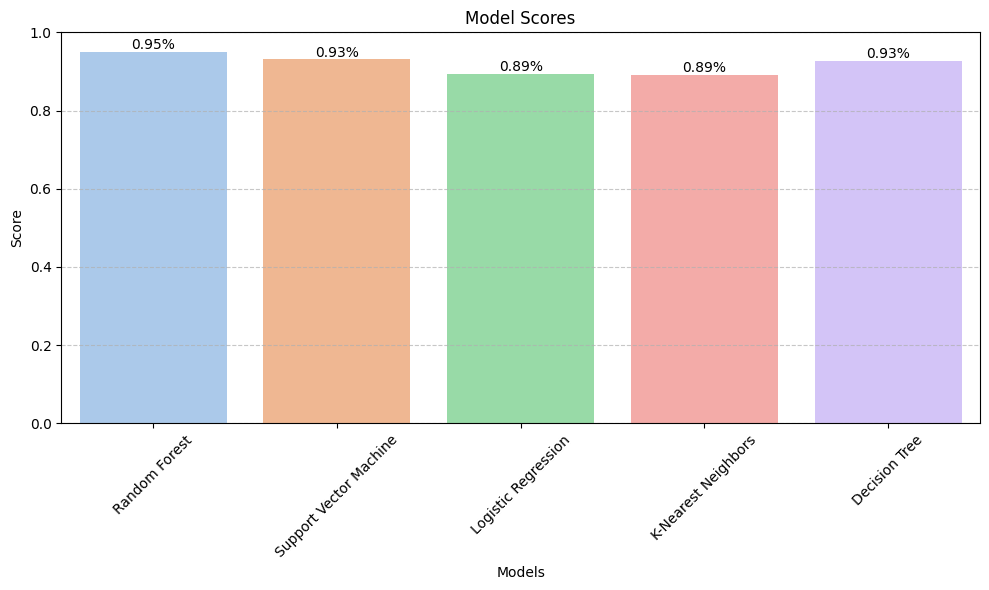

In [25]:
# Define a color palette for the bars
colors = sns.color_palette('pastel', n_colors=len(scores_df))

# Create a bar plot of models and their scores
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Accuracy', data=scores_df, palette=colors)

# Add text on each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Model Scores')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


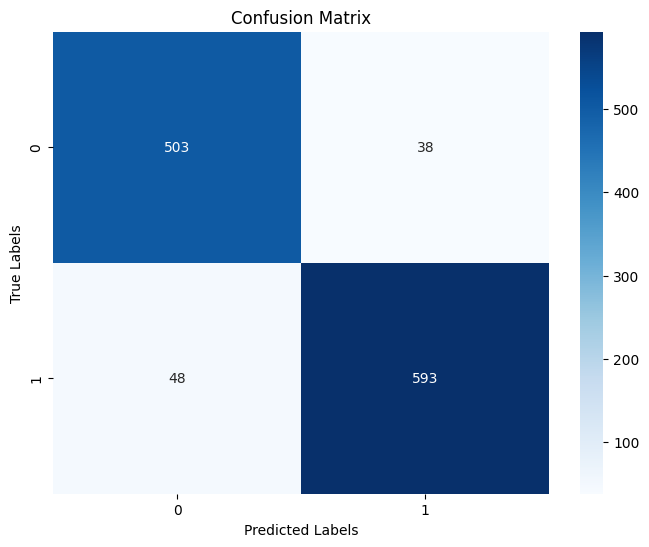

In [26]:
# Compute confusion matrix
conf_matrix = confusion_matrix(yr_test, y_pred)

# Display confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#import pickle
#with open("telco_model.pkl", "wb") as file:
 #   pickle.dump(model, file)

In [30]:
import pickle
#Save both model AND feature columns together
feature_columns = list(Xr_train.columns)

with open("telecom_model.pkl", "wb") as f:
    pickle.dump((best_model, feature_columns), f, protocol=4)

print("✅ Model saved successfully!")
print(f"Features saved: {len(feature_columns)} columns")

✅ Model saved successfully!
Features saved: 45 columns


In [27]:
!pip install shap

In [33]:
print("sv shape:", sv.shape)
print("Xr_test_scaled shape:", Xr_test_scaled.shape)
print("Xr_test columns:", len(Xr_test.columns.tolist()))
print("Type of shap_values:", type(shap_values))
if isinstance(shap_values, list):
    print("shap_values[0] shape:", shap_values[0].shape)
    print("shap_values[1] shape:", shap_values[1].shape)

sv shape: (45, 2)
Xr_test_scaled shape: (1182, 45)
Xr_test columns: 45
Type of shap_values: <class 'numpy.ndarray'>


sv shape: (1182, 45)


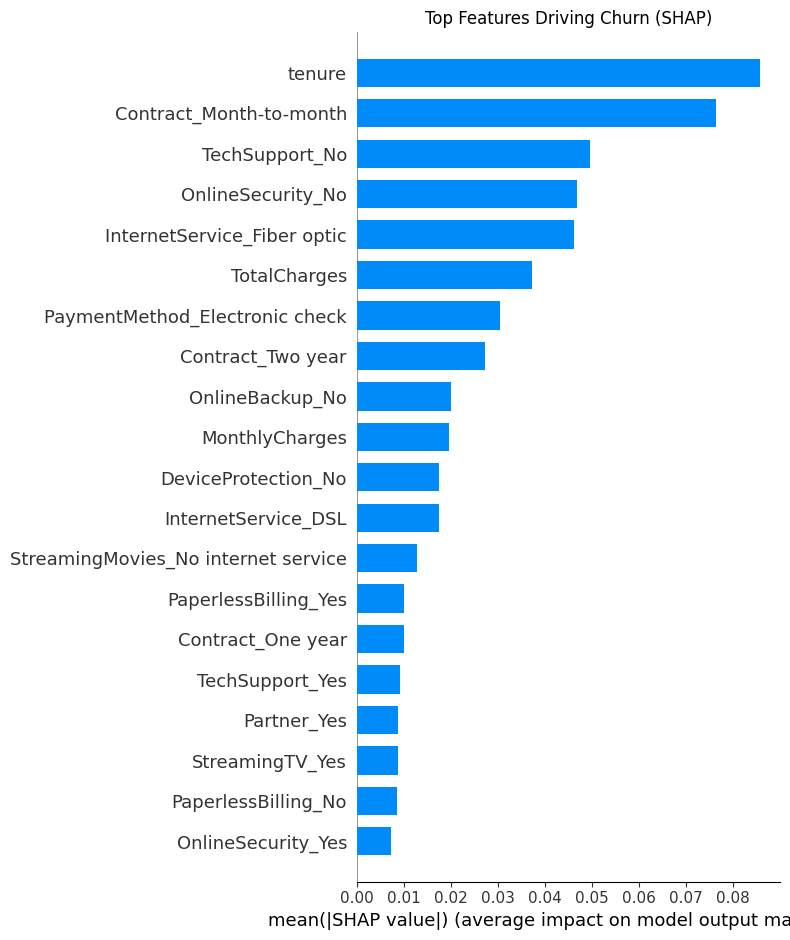

✅ Plot 1 done!


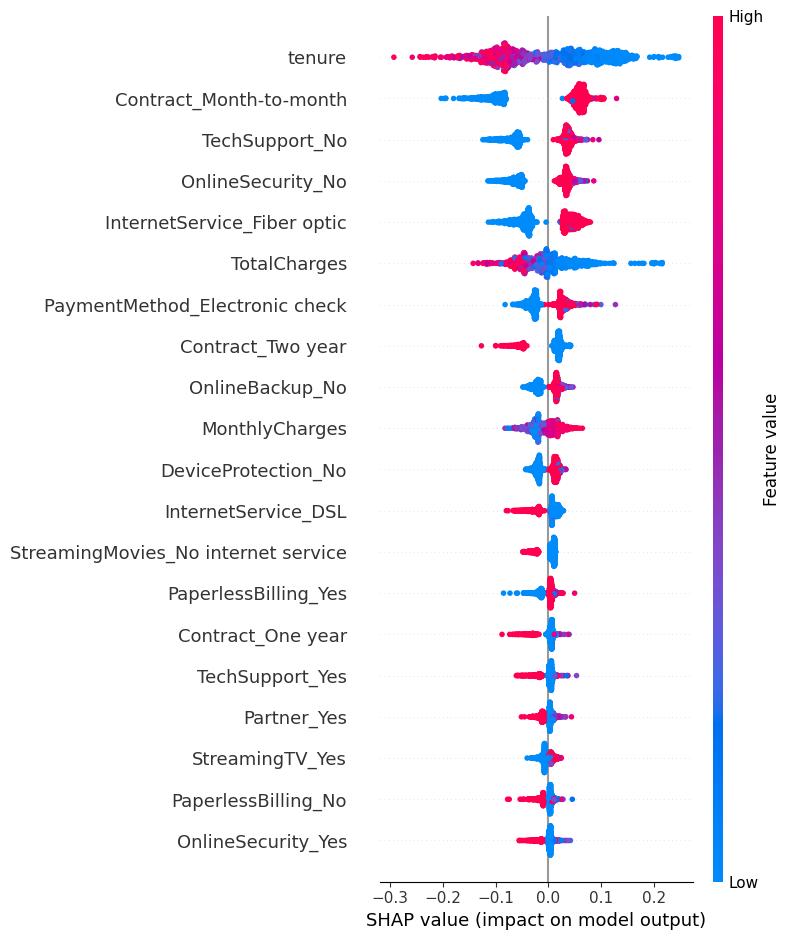

✅ Plot 2 done!


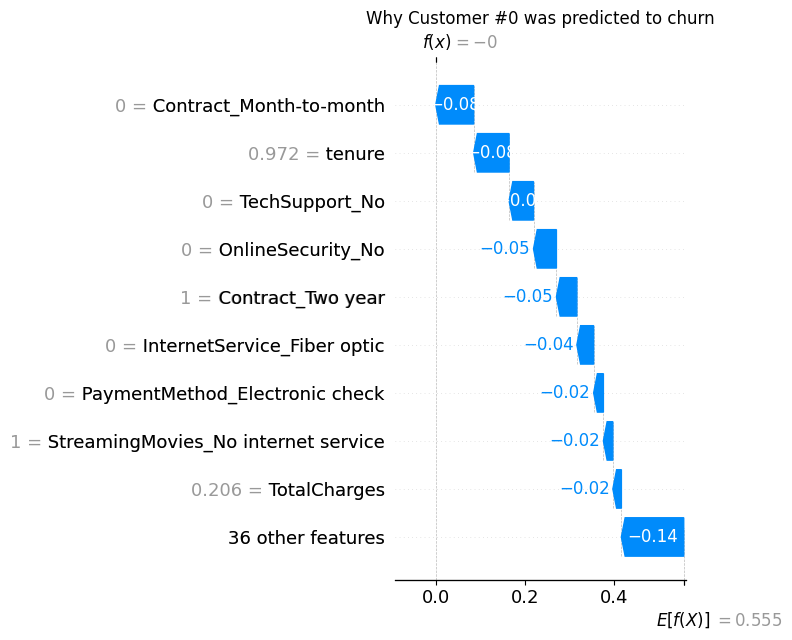

✅ Plot 3 done!


In [35]:
# ============================================================
# STEP 2 — SHAP (Explainable AI)
# ============================================================

import shap
import matplotlib.pyplot as plt
import numpy as np

base_classifier = best_model.named_steps['model']
scaler = best_model.named_steps['scaler']
Xr_test_scaled = scaler.transform(Xr_test)

explainer = shap.TreeExplainer(base_classifier)
shap_values = explainer.shap_values(Xr_test_scaled)

# shape is (1182, 45, 2) → slice churn class (index 1)
sv = shap_values[:, :, 1]
print("sv shape:", sv.shape)  # should be (1182, 45) now ✅

# ── Plot 1: Feature Importance (Bar) ─────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, Xr_test_scaled,
    feature_names=Xr_test.columns.tolist(),
    plot_type="bar", show=False)
plt.title("Top Features Driving Churn (SHAP)")
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 1 done!")

# ── Plot 2: Beeswarm ──────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, Xr_test_scaled,
    feature_names=Xr_test.columns.tolist(), show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 2 done!")

# ── Plot 3: Single Customer Waterfall ────────────────────────
customer_index = 0
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = float(np.array(base_val).flat[1])

shap.waterfall_plot(
    shap.Explanation(
        values=sv[customer_index],
        base_values=base_val,
        data=Xr_test_scaled[customer_index],
        feature_names=Xr_test.columns.tolist()
    ), show=False)
plt.title(f"Why Customer #{customer_index} was predicted to churn")
plt.tight_layout()
plt.savefig("shap_single_customer.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 3 done!")




📊 Customer Risk Segmentation Summary:
             Customer Count  Avg Churn Probability    Min    Max
Risk_Tier                                                       
High Risk               575                  0.962  0.745  1.000
Low Risk                491                  0.051  0.000  0.285
Medium Risk             116                  0.519  0.290  0.740


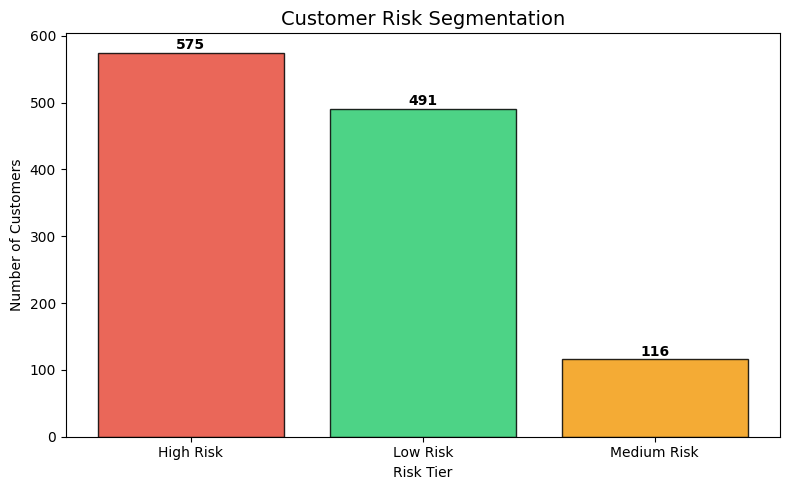

✅ Risk segmentation plot saved!


In [36]:
# ============================================================
# STEP 3 — Customer Risk Segmentation (K-Means Clustering)
# ============================================================

from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get churn probabilities for all resampled test customers
churn_proba = best_model.predict_proba(Xr_test)[:, 1]  # probability of churn

# Segment into 3 risk tiers using KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
risk_clusters = kmeans.fit_predict(churn_proba.reshape(-1, 1))

# Map cluster numbers to risk labels based on mean churn probability
cluster_means = {}
for c in range(3):
    cluster_means[c] = churn_proba[risk_clusters == c].mean()

# Sort clusters by churn probability → assign Low/Medium/High
sorted_clusters = sorted(cluster_means, key=cluster_means.get)
label_map = {
    sorted_clusters[0]: 'Low Risk',
    sorted_clusters[1]: 'Medium Risk',
    sorted_clusters[2]: 'High Risk'
}
risk_labels = [label_map[c] for c in risk_clusters]

# Build summary dataframe
risk_df = Xr_test.copy()
risk_df['Churn_Probability'] = churn_proba
risk_df['Risk_Tier'] = risk_labels

# ── Summary Table ─────────────────────────────────────────────
summary = risk_df.groupby('Risk_Tier')['Churn_Probability'].agg(['count', 'mean', 'min', 'max'])
summary.columns = ['Customer Count', 'Avg Churn Probability', 'Min', 'Max']
summary['Avg Churn Probability'] = summary['Avg Churn Probability'].round(3)
print("\n📊 Customer Risk Segmentation Summary:")
print(summary)

# ── Plot ──────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
colors = {'Low Risk': '#2ecc71', 'Medium Risk': '#f39c12', 'High Risk': '#e74c3c'}
risk_counts = risk_df['Risk_Tier'].value_counts()
plt.bar(risk_counts.index, risk_counts.values,
        color=[colors[r] for r in risk_counts.index], edgecolor='black', alpha=0.85)
plt.title('Customer Risk Segmentation', fontsize=14)
plt.xlabel('Risk Tier')
plt.ylabel('Number of Customers')
for i, (label, val) in enumerate(zip(risk_counts.index, risk_counts.values)):
    plt.text(i, val + 5, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("risk_segmentation.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Risk segmentation plot saved!")


In [37]:
!pip install google-generativeai

In [57]:
# ============================================================
# STEP 4 — GenAI Retention Recommendations (Gemini API)
# ============================================================



import google.generativeai as genai

GEMINI_API_KEY = ""
genai.configure(api_key=GEMINI_API_KEY)
gemini_model = genai.GenerativeModel("models/gemini-2.5-flash")

def generate_retention_strategy(customer_data: dict, churn_prob: float, risk_tier: str) -> str:
    """
    Sends customer profile to Gemini and gets a retention recommendation
    """
    prompt = f"""
You are a telecom customer retention expert.

A customer has been flagged as '{risk_tier}' with a {churn_prob:.0%} probability of churning.

Customer Profile:
- Contract Type: {customer_data.get('Contract', 'Unknown')}
- Monthly Charges: ${customer_data.get('MonthlyCharges', 'Unknown')}
- Tenure: {customer_data.get('tenure', 'Unknown')} months
- Internet Service: {customer_data.get('InternetService', 'Unknown')}
- Payment Method: {customer_data.get('PaymentMethod', 'Unknown')}

Give 3 specific, actionable retention strategies for this customer in plain English.
Keep it concise — max 3 bullet points. Focus on what the business should actually do.
"""
    response = gemini_model.generate_content(prompt)
    return response.text


# ── Test on 3 sample customers ────────────────────────────────
print("🤖 AI-Powered Retention Recommendations\n")
print("=" * 60)

# Get original (un-encoded) test data for readable output
# We'll use the churn probability and risk tier from Step 3
sample_indices = [0, 1, 2]  # try first 3 customers

import time

for idx in sample_indices:
    prob = float(churn_proba[idx])
    tier = risk_labels[idx]

    customer_sample = {
        'tenure': int(Xr_test.iloc[idx].get('tenure', 12)),
        'MonthlyCharges': float(Xr_test.iloc[idx].get('MonthlyCharges', 70)),
        'Contract': 'Month-to-month',
        'InternetService': 'Fiber optic',
        'PaymentMethod': 'Electronic check',
        'SeniorCitizen': 'No'
    }

    print(f"\n👤 Customer #{idx} | Risk: {tier} | Churn Probability: {prob:.1%}")
    print("-" * 60)
    recommendation = generate_retention_strategy(customer_sample, prob, tier)
    print(recommendation)
    print("=" * 60)

    time.sleep(60)  # wait 60 seconds between each call — free tier limit


print("\n✅ GenAI retention strategies generated!")

🤖 AI-Powered Retention Recommendations


👤 Customer #0 | Risk: Low Risk | Churn Probability: 0.0%
------------------------------------------------------------
Here are 3 specific, actionable retention strategies for this customer:

*   **Offer a 'Loyalty Appreciation' discount for auto-pay:** Proactively reach out to thank them for their 70 months of loyalty. Offer a recurring discount (e.g., $5 off per month for the next 12 months) specifically if they switch their electronic check payment to convenient auto-pay via credit card or bank account, reinforcing stickiness and making payments easier.
*   **Conduct a proactive 'Fiber Value Check-up':** Schedule a brief, non-salesy call or send a personalized email inviting them to a "Fiber Value Check-up." The goal is to ensure they are still maximizing their fiber optic service for their $25.4 monthly charge and to subtly ascertain if there are any new features or services (like advanced Wi-Fi extenders or security features) that could genu

In [58]:
# ============================================================
# STEP 5 — Updated model save
# ============================================================

import pickle

# Save model + feature columns (for Streamlit app)
with open("telecom_model.pkl", "wb") as f:
    pickle.dump((best_model, list(Xr_train.columns)), f, protocol=4)

# Save risk segmentation results
risk_df.to_csv("customer_risk_segments.csv", index=False)

print("✅ All files saved:")
print("   - telecom_model.pkl")
print("   - customer_risk_segments.csv")
print("   - shap_feature_importance.png")
print("   - shap_summary.png")
print("   - shap_single_customer.png")
print("   - risk_segmentation.png")

✅ All files saved:
   - telecom_model.pkl
   - customer_risk_segments.csv
   - shap_feature_importance.png
   - shap_summary.png
   - shap_single_customer.png
   - risk_segmentation.png
